Distribuição térmica:
[[ 75.   100.   100.   100.   100.   100.    50.  ]
 [ 75.    83.59  84.93  83.77  80.58  72.65  50.  ]
 [ 75.    74.42  72.35  69.57  65.91  60.02  50.  ]
 [ 75.    66.74  60.48  56.25  53.46  51.53  50.  ]
 [ 75.    57.04  46.59  41.49  40.15  42.65  50.  ]
 [ 75.    39.85  27.35  22.96  23.01  28.91  50.  ]
 [ 75.     0.     0.     0.     0.     0.    50.  ]]


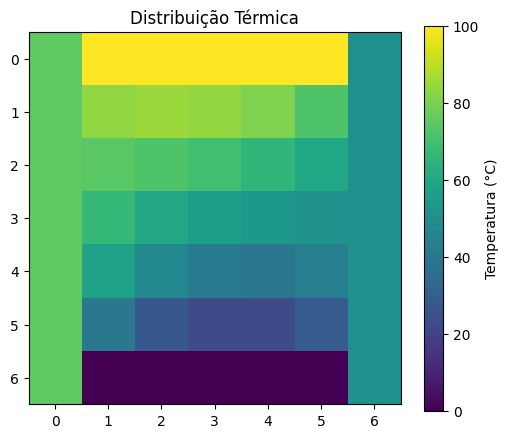

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================
# SIMULAÇÃO TÉRMICA - MALHA 5x5
# ============================

n = 5

# Matriz completa (com bordas)
T = np.zeros((n+2, n+2))

# Condições de contorno
T[0, :] = 100     # topo
T[-1, :] = 0      # base
T[:, 0] = 75      # esquerda
T[:, -1] = 50     # direita

# Inicialização interna
T[1:-1, 1:-1] = 50

# Método iterativo
for _ in range(1000):
    T_old = T.copy()

    for i in range(1, n+1):
        for j in range(1, n+1):
            T[i, j] = 0.25 * (
                T_old[i+1, j] +
                T_old[i-1, j] +
                T_old[i, j+1] +
                T_old[i, j-1]
            )

# Resultados
print("Distribuição térmica:")
print(np.round(T, 2))

# Gráfico
plt.figure(figsize=(6,5))
plt.imshow(T, origin='upper')
plt.colorbar(label='Temperatura (°C)')
plt.title('Distribuição Térmica')
plt.show()